Imports and download the VADER lexicon

In [ ]:
import re
import matplotlib.pyplot as plt
import nltk
import pandas as pd
import seaborn as sns
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download("vader_lexicon")

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

Sample reviews to analyze

In [ ]:
reviews = [
    "This product is absolutely amazing! Best purchase ever.",
    "Terrible quality, broke after one day. Very disappointed.",
    "It's okay, does the job but nothing special.",
    "I love it!!! Highly recommend to everyone :)",
    "Not good at all, waste of money.",
    "The delivery was on time and the packaging was fine.",
    "Worst experience, customer service was rude and unhelpful.",
    "Great value for the price, works perfectly.",
]


Text cleaning function

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s!?:)(]", "", text)
    return text.strip()

Run sentiment analysis on each review

In [ ]:
sia = SentimentIntensityAnalyzer()
results = []

for review in reviews:
    cleaned = clean_text(review)
    scores = sia.polarity_scores(cleaned)

    if scores["compound"] >= 0.05:
        label = "Positive"
    elif scores["compound"] <= -0.05:
        label = "Negative"
    else:
        label = "Neutral"

    results.append(
        {"review": review, "compound": scores["compound"], "sentiment": label}
    )

df = pd.DataFrame(results)
print(df)

                                              review  compound sentiment
0  This product is absolutely amazing! Best purch...    0.8709  Positive
1  Terrible quality, broke after one day. Very di...   -0.8516  Negative
2       It's okay, does the job but nothing special.   -0.3479  Negative
3       I love it!!! Highly recommend to everyone :)    0.8972  Positive
4                   Not good at all, waste of money.   -0.6377  Negative
5  The delivery was on time and the packaging was...    0.2023  Positive
6  Worst experience, customer service was rude an...   -0.7964  Negative
7        Great value for the price, works perfectly.    0.8934  Positive


Sentiment distribution summary

In [ ]:
sentiment_counts = df["sentiment"].value_counts()
print("\nSentiment Distribution:\n", sentiment_counts)


Sentiment Distribution:
 sentiment
Positive    4
Negative    4
Name: count, dtype: int64


Plot and save the sentiment distribution

/tmp/ipykernel_1235/529552226.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


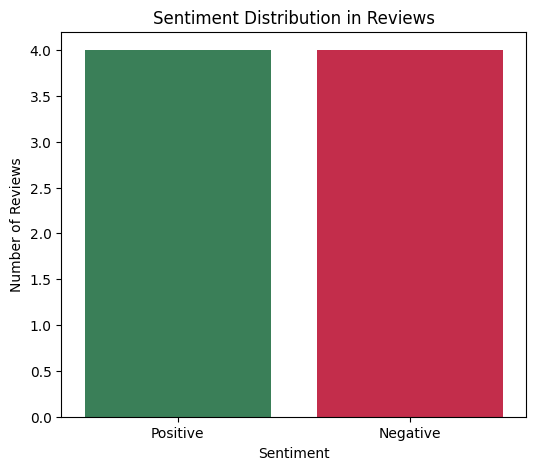

In [ ]:
plt.figure(figsize=(6, 5))
sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values,
    palette={
        "Positive": "seagreen",
        "Negative": "crimson",
        "Neutral": "gray",
    },
)
plt.title("Sentiment Distribution in Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.savefig("sentiment_distribution.png")
plt.show()

Save results to CSV

In [ ]:
df.to_csv("sentiment_results.csv", index=False, encoding="utf-8-sig")